<a href="https://colab.research.google.com/github/nigusalene2-cyber/MCP-ML-Project/blob/main/MLproject_Nigus_Alene_Assefa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MCP DOSIMETER MACHINE LEARNING PROJECT

Generating data...
Dataset shape: (1000, 12)
Columns: ['field_type', 'deep_dose', 'shallow_dose', 'neutron_dose', 'L1', 'L2', 'L3', 'L4', 'ratio_L3_L2', 'ratio_L3_L1', 'ratio_L2_L4', 'ratio_L1_L2']

First 5 rows:
             field_type  deep_dose  shallow_dose  neutron_dose           L1  \
0     mixed_photon_beta  79.674644    170.664822      0.000000   782.820007   
1               neutron  96.993994    109.891970     48.831075   914.779570   
2                  beta  97.378176    225.401235      0.000000  1006.931868   
3         photon_medium  94.893665    112.567877      0.000000   919.683633   
4  mixed_photon_neutron  39.166955     34.188617     60.128587   363.398930   

            L2           L3           L4  ratio_L3_L2  ratio_L3_L1  \
0   842.871737  1641.198819   777.086170     1.947151     2.096521   
1   936.699747  1089.684846  1327.036840     1.163324     1.191199   
2   934.428035  2246.226902  1009.282472     2.403852     2.23

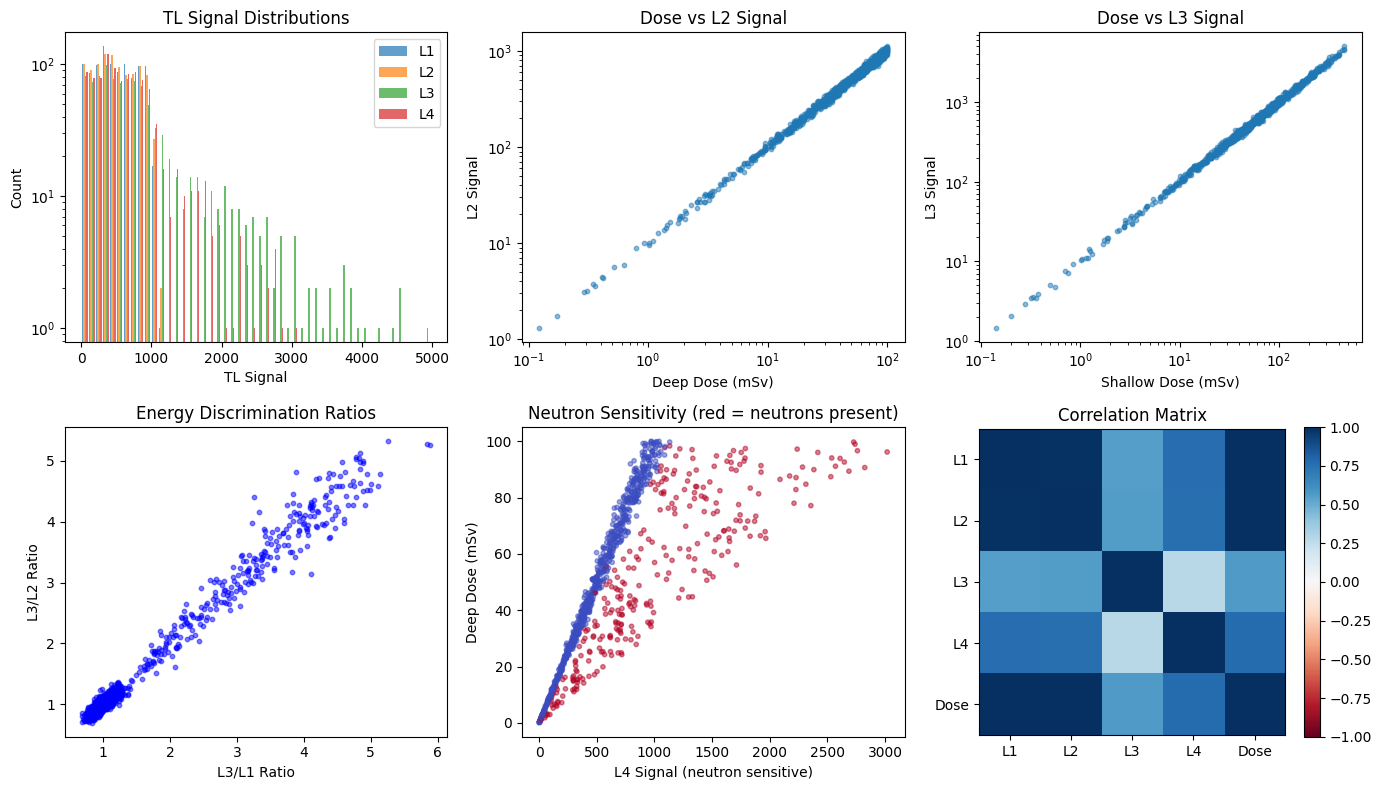


Training samples: 800
Test samples: 200
Features: ['L1', 'L2', 'L3', 'L4', 'ratio_L3_L2', 'ratio_L3_L1', 'ratio_L2_L4', 'ratio_L1_L2']

MODEL PERFORMANCE COMPARISON
Model                MAE        MSE        R²         CV R²       
------------------------------------------------------------
Ridge                1.510      4.293      0.995      0.994       
Lasso                1.489      4.244      0.995      0.994       
Random Forest        1.398      3.610      0.996      0.994       
Gradient Boosting    1.361      3.510      0.996      0.994       
Neural Network       1.467      4.217      0.995      0.994       

BEST MODEL (by R² score)
Model    Gradient Boosting
MAE               1.361297
MSE               3.510197
R2                0.995666
CV_R2             0.994261


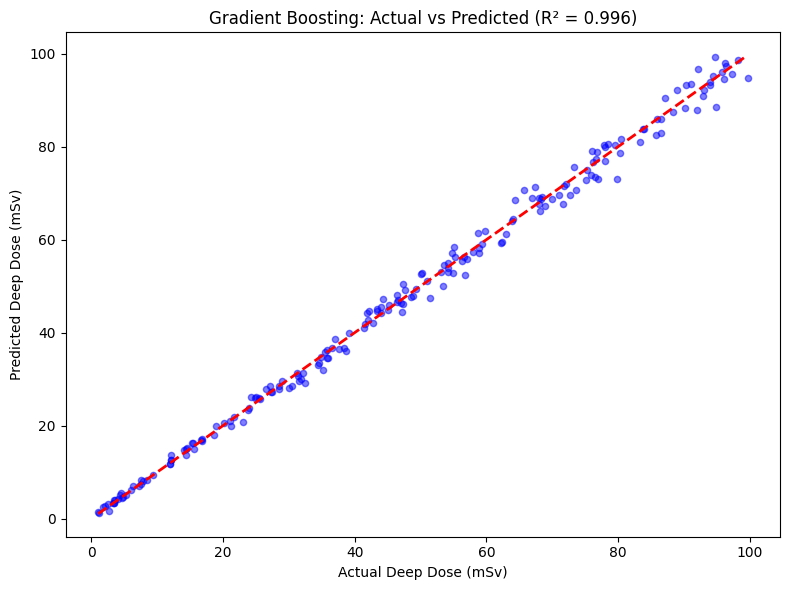

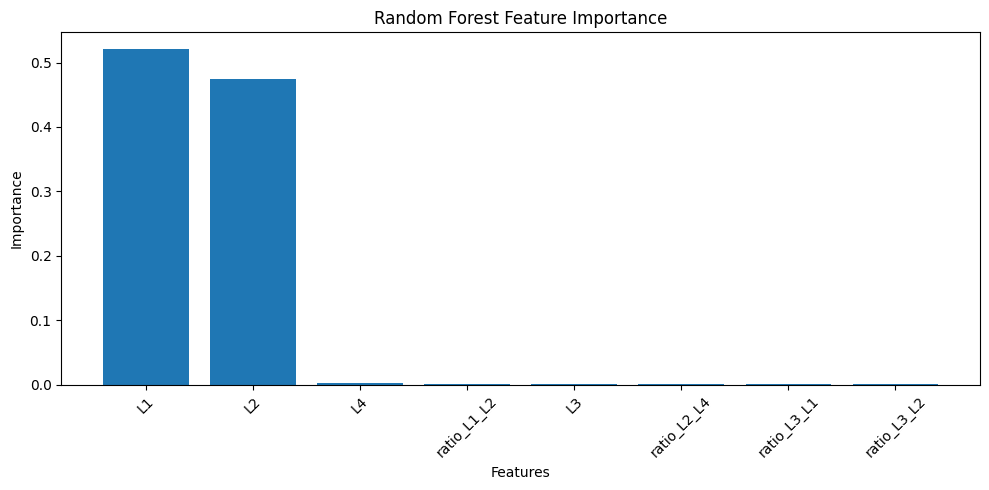


Feature Importance (Random Forest):
  L1: 0.521
  L2: 0.474
  L4: 0.002
  ratio_L1_L2: 0.001
  L3: 0.001
  ratio_L2_L4: 0.001
  ratio_L3_L1: 0.000
  ratio_L3_L2: 0.000

PROJECT SUMMARY
✓ Dataset: 1000 synthetic MCP dosimeter samples
✓ Features: 8 (4 raw signals + 4 ratios)
✓ Target: Deep dose equivalent (mSv)
✓ Models tested: 5 regression algorithms
✓ Best model: Gradient Boosting (R² = 0.996)
✓ Cross-validation: 5-fold, mean R² = 0.994


In [1]:
# ============================================
# MCP DOSIMETER MACHINE LEARNING PROJECT
# Course: Machine Learning
# Student: Nigus Alene Assefa
# ============================================
#
# PROBLEM:
# MCP dosimeters have 4 sensors (L1, L2, L3, L4) that measure radiation.
# From these 4 values, we need to predict the radiation dose (deep_dose).
# This is a regression problem.
#
# DATA:
# 1000 synthetic samples based on real MCP physics
# 7 radiation field types: photons (low/medium/high energy), beta, neutron, mixed fields
#
# METHODS:
# 5 regression algorithms: Ridge, Lasso, Random Forest, Gradient Boosting, Neural Network
#
# EVALUATION:
# MAE, MSE, R², 5-fold cross-validation
#
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: GENERATE SYNTHETIC DATA
# ============================================

np.random.seed(42)

def generate_mcp_data(n_samples=1000):
    """Generate synthetic MCP dosimeter data based on physical principles"""

    field_types = ['photon_low', 'photon_medium', 'photon_high',
                   'beta', 'neutron', 'mixed_photon_neutron', 'mixed_photon_beta']

    data = []

    for i in range(n_samples):
        field = np.random.choice(field_types)

        # True doses
        deep_dose = np.random.uniform(0.1, 100)

        if 'beta' in field:
            shallow_dose = deep_dose * np.random.uniform(1.5, 5)
        else:
            shallow_dose = deep_dose * np.random.uniform(0.8, 1.2)

        if 'neutron' in field:
            neutron_dose = deep_dose * np.random.uniform(0.1, 2)
        else:
            neutron_dose = 0

        # Energy factor
        if field == 'photon_low':
            energy_factor = 1.06
        elif field == 'photon_medium':
            energy_factor = 1.02
        else:
            energy_factor = 1.00

        base_response = 10

        # TL signals (4 elements)
        L1 = deep_dose * base_response * energy_factor * np.random.normal(1, 0.05)
        L2 = deep_dose * base_response * energy_factor * np.random.normal(1, 0.05)
        L3 = shallow_dose * base_response * energy_factor * np.random.normal(1, 0.05)
        L4 = (deep_dose + neutron_dose) * base_response * np.random.normal(1, 0.05)

        # Add noise
        L1 += np.random.normal(0, L1 * 0.02)
        L2 += np.random.normal(0, L2 * 0.02)
        L3 += np.random.normal(0, L3 * 0.02)
        L4 += np.random.normal(0, L4 * 0.02)

        data.append({
            'field_type': field,
            'deep_dose': deep_dose,
            'shallow_dose': shallow_dose,
            'neutron_dose': neutron_dose,
            'L1': L1, 'L2': L2, 'L3': L3, 'L4': L4
        })

    df = pd.DataFrame(data)

    # Add engineered features (ratios)
    df['ratio_L3_L2'] = df['L3'] / df['L2']
    df['ratio_L3_L1'] = df['L3'] / df['L1']
    df['ratio_L2_L4'] = df['L2'] / df['L4']
    df['ratio_L1_L2'] = df['L1'] / df['L2']

    return df

print("="*60)
print("MCP DOSIMETER MACHINE LEARNING PROJECT")
print("="*60)
print("\nGenerating data...")
df = generate_mcp_data(1000)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

# ============================================
# STEP 2: VISUALIZE DATA
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Plot 1: Signal distributions
axes[0,0].hist([df['L1'], df['L2'], df['L3'], df['L4']], bins=50, alpha=0.7, label=['L1','L2','L3','L4'])
axes[0,0].set_xlabel('TL Signal')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('TL Signal Distributions')
axes[0,0].legend()
axes[0,0].set_yscale('log')

# Plot 2: Deep dose vs L2
axes[0,1].scatter(df['deep_dose'], df['L2'], alpha=0.5, s=10)
axes[0,1].set_xlabel('Deep Dose (mSv)')
axes[0,1].set_ylabel('L2 Signal')
axes[0,1].set_title('Dose vs L2 Signal')
axes[0,1].set_xscale('log')
axes[0,1].set_yscale('log')

# Plot 3: Shallow dose vs L3
axes[0,2].scatter(df['shallow_dose'], df['L3'], alpha=0.5, s=10)
axes[0,2].set_xlabel('Shallow Dose (mSv)')
axes[0,2].set_ylabel('L3 Signal')
axes[0,2].set_title('Dose vs L3 Signal')
axes[0,2].set_xscale('log')
axes[0,2].set_yscale('log')

# Plot 4: Energy ratios
axes[1,0].scatter(df['ratio_L3_L1'], df['ratio_L3_L2'], alpha=0.5, s=10, c='blue')
axes[1,0].set_xlabel('L3/L1 Ratio')
axes[1,0].set_ylabel('L3/L2 Ratio')
axes[1,0].set_title('Energy Discrimination Ratios')

# Plot 5: Neutron sensitivity
has_neutron = df['neutron_dose'] > 0
axes[1,1].scatter(df['L4'], df['deep_dose'], c=has_neutron, alpha=0.5, s=10, cmap='coolwarm')
axes[1,1].set_xlabel('L4 Signal (neutron sensitive)')
axes[1,1].set_ylabel('Deep Dose (mSv)')
axes[1,1].set_title('Neutron Sensitivity (red = neutrons present)')

# Plot 6: Correlation matrix
corr = df[['L1', 'L2', 'L3', 'L4', 'deep_dose']].corr()
im = axes[1,2].imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
axes[1,2].set_xticks(range(5))
axes[1,2].set_yticks(range(5))
axes[1,2].set_xticklabels(['L1','L2','L3','L4','Dose'])
axes[1,2].set_yticklabels(['L1','L2','L3','L4','Dose'])
axes[1,2].set_title('Correlation Matrix')
plt.colorbar(im, ax=axes[1,2])

plt.tight_layout()
plt.savefig('mcp_visualization.png', dpi=150)
plt.show()

# ============================================
# STEP 3: PREPARE DATA FOR MACHINE LEARNING
# ============================================

# Features (4 signals + 4 ratios)
feature_cols = ['L1', 'L2', 'L3', 'L4', 'ratio_L3_L2', 'ratio_L3_L1', 'ratio_L2_L4', 'ratio_L1_L2']
X = df[feature_cols]
y = df['deep_dose']  # Predicting deep dose

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {feature_cols}")

# ============================================
# STEP 4: DEFINE MODELS AND SCALERS
# ============================================

# Models
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
}

# Scalers
scaler_linear = StandardScaler()   # For Ridge, Lasso, Neural Network
scaler_tree = RobustScaler()        # For Random Forest, Gradient Boosting

# Apply scalers
X_train_linear = scaler_linear.fit_transform(X_train)
X_test_linear = scaler_linear.transform(X_test)
X_train_tree = scaler_tree.fit_transform(X_train)
X_test_tree = scaler_tree.transform(X_test)

# ============================================
# STEP 5: TRAIN AND EVALUATE MODELS
# ============================================

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(f"{'Model':<20} {'MAE':<10} {'MSE':<10} {'R²':<10} {'CV R²':<12}")
print("-"*60)

results = []

for name, model in models.items():
    # Choose scaler
    if name in ['Ridge', 'Lasso', 'Neural Network']:
        X_train_scaled = X_train_linear
        X_test_scaled = X_test_linear
    else:
        X_train_scaled = X_train_tree
        X_test_scaled = X_test_tree

    # Train model
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Cross-validation (5-fold)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()

    # Store results
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'R2': r2,
        'CV_R2': cv_mean
    })

    print(f"{name:<20} {mae:<10.3f} {mse:<10.3f} {r2:<10.3f} {cv_mean:<12.3f}")

# ============================================
# STEP 6: FIND BEST MODEL AND VISUALIZE
# ============================================

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)

print("\n" + "="*60)
print("BEST MODEL (by R² score)")
print("="*60)
print(results_df.iloc[0].to_string())

# Plot predictions of best model
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]

# Retrain best model on scaled data
if best_name in ['Ridge', 'Lasso', 'Neural Network']:
    best_model.fit(X_train_linear, y_train)
    y_pred_best = best_model.predict(X_test_linear)
else:
    best_model.fit(X_train_tree, y_train)
    y_pred_best = best_model.predict(X_test_tree)

# Create prediction plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, s=20, c='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Deep Dose (mSv)')
plt.ylabel('Predicted Deep Dose (mSv)')
plt.title(f'{best_name}: Actual vs Predicted (R² = {results_df.iloc[0]["R2"]:.3f})')
plt.tight_layout()
plt.savefig('best_model_predictions.png', dpi=150)
plt.show()

# ============================================
# STEP 7: FEATURE IMPORTANCE (for Random Forest)
# ============================================

if 'Random Forest' in models:
    rf_model = models['Random Forest']
    rf_model.fit(X_train_tree, y_train)
    importances = rf_model.feature_importances_

    plt.figure(figsize=(10, 5))
    indices = np.argsort(importances)[::-1]
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=45)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

    print("\nFeature Importance (Random Forest):")
    for i in range(len(importances)):
        print(f"  {feature_cols[indices[i]]}: {importances[indices[i]]:.3f}")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)
print(f"✓ Dataset: 1000 synthetic MCP dosimeter samples")
print(f"✓ Features: 8 (4 raw signals + 4 ratios)")
print(f"✓ Target: Deep dose equivalent (mSv)")
print(f"✓ Models tested: 5 regression algorithms")
print(f"✓ Best model: {best_name} (R² = {results_df.iloc[0]['R2']:.3f})")
print(f"✓ Cross-validation: 5-fold, mean R² = {results_df.iloc[0]['CV_R2']:.3f}")
print("="*60)